In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 5
fig_height = 4
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "LinearAlgebra", "Plots", "DifferentialEquations", "LaTeXStrings", "NLSolve"]

6-element Vector{String}:
 "SymPyPythonCall"
 "LinearAlgebra"
 "Plots"
 "DifferentialEquations"
 "LaTeXStrings"
 "NLSolve"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
  [0c46a032] DifferentialEquations v8.0.2
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [bc8888f7] SymPyPythonCall v0.5.1
  [37e2e46d] LinearAlgebra v1.12.0


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
function campo_vectorial(f, g, xs, ys; escala = 0.35, kwargs...)
    X = [x for y in ys for x in xs]
    Y = [y for y in ys for x in xs]
    U = f.(X, Y)
    V = g.(X, Y)
    N = sqrt.(U .^ 2 .+ V .^ 2) .+ 1e-12
    quiver(X, Y, quiver = (escala * U ./ N, escala * V ./ N),
           color = :gray, alpha = 0.7; kwargs...)
end;

In [10]:
using SymPyPythonCall
@syms x y
f = x * (3 - x - 2y)
g = y * (2 - x - y)
equilibrios = solve([f, g], [x, y])

4-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}}}:
 (0, 0)
 (0, 2)
 (1, 1)
 (3, 0)

In [11]:
J = [diff(f, x) diff(f, y); diff(g, x) diff(g, y)]

2×2 Matrix{Sym{PythonCall.Py}}:
 -2⋅x - 2⋅y + 3          -2⋅x
             -y  -x - 2⋅y + 2

In [12]:
using LinearAlgebra
for eq in equilibrios
    Je = J.subs(Dict(x => eq[1], y => eq[2]))
    vals = eigvals(Float64.(Je))
    println("Equilibrio $eq → autovalores $(round.(vals, digits=3))")
end

Equilibrio (0, 0) → autovalores [2.0, 3.0]


Equilibrio (0, 2) → autovalores [-2.0, -1.0]
Equilibrio (1, 1) → autovalores [-2.414, 0.414]
Equilibrio (3, 0) → autovalores [-3.0, -1.0]


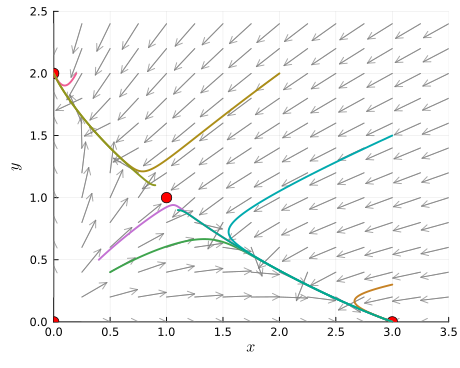

In [13]:
using Plots, LaTeXStrings, DifferentialEquations
fn(x, y) = x * (3 - x - 2y)
gn(x, y) = y * (2 - x - y)
plt = campo_vectorial(fn, gn, 0:0.25:3.5, 0:0.2:2.5, escala = 0.25,
    xlab = L"x", ylab = L"y", legend = false, xlims = (0, 3.5), ylims = (0, 2.5))
scatter!(plt, [0,3,0,1], [0,0,2,1], color = :red, ms = 6)
function comp!(du, u, p, t)
    du[1] = fn(u[1], u[2]); du[2] = gn(u[1], u[2])
end
for u0 in [[0.5,0.4],[0.4,0.5],[2,2],[3,1.5],[0.2,2],[3,0.3],[1.1,0.9],[0.9,1.1]]
    sol = solve(ODEProblem(comp!, float.(u0), (0.0, 15.0)))
    plot!(plt, sol, idxs = (1, 2), lw = 2)
end
plt

In [14]:
using LinearAlgebra
μ = 1.5
J0 = [0 1.0; -1 μ]      # Jacobiana en (0,0)
eigvals(J0)

2-element Vector{ComplexF64}:
 0.75 - 0.6614378277661476im
 0.75 + 0.6614378277661476im

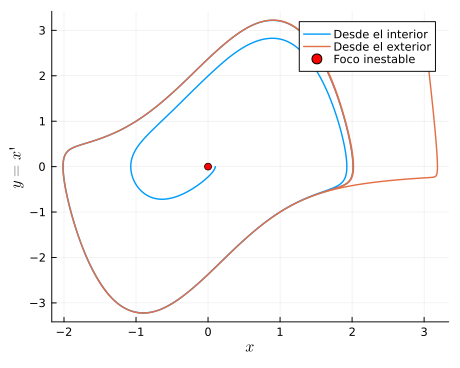

In [15]:
using Plots, LaTeXStrings, DifferentialEquations
function vdp!(du, u, p, t)
    du[1] = u[2]
    du[2] = 1.5 * (1 - u[1]^2) * u[2] - u[1]
end
plt = plot(xlab = L"x", ylab = L"y = x'", legend = :topright)
for (u0, lab) in [([0.1, 0.0], "Desde el interior"),
                  ([3.0, 3.0], "Desde el exterior")]
    sol = solve(ODEProblem(vdp!, u0, (0.0, 30.0)), saveat = 0.01)
    plot!(plt, sol[1, :], sol[2, :], lw = 1.5, label = lab)
end
scatter!(plt, [0], [0], color = :red, label = "Foco inestable")
plt

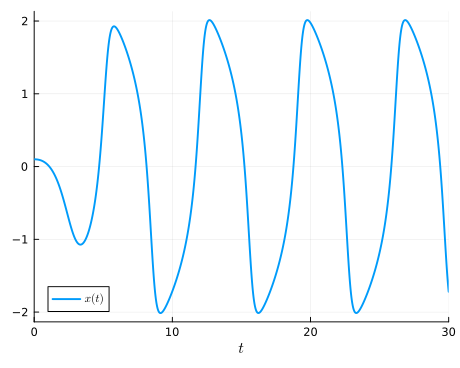

In [16]:
sol = solve(ODEProblem(vdp!, [0.1, 0.0], (0.0, 30.0)), saveat = 0.01)
plot(sol, idxs = 1, lw = 2, label = L"x(t)", xlab = L"t")

In [17]:
using NLsolve
I = 0.0
F(u) = [u[1] - u[1]^3/3 - u[2] + I, 0.08*(u[1] + 0.7 - 0.8u[2])]
eq = nlsolve(F, [-1.2, -0.6]).zero

2-element Vector{Float64}:
 -1.1994080352440788
 -0.6242600440550986

In [18]:
using SymPyPythonCall, LinearAlgebra
@syms v w
fv = v - v^3/3 - w + I
gw = Sym(8)/100 * (v + Sym(7)/10 - Sym(8)/10 * w)
Jsym = [diff(fv,v) diff(fv,w); diff(gw,v) diff(gw,w)]
Je = Float64.(Jsym.subs(Dict(v => eq[1], w => eq[2])))
eigvals(Je)

2-element Vector{ComplexF64}:
 -0.2512898175040307 - 0.21194934361612663im
 -0.2512898175040307 + 0.21194934361612663im

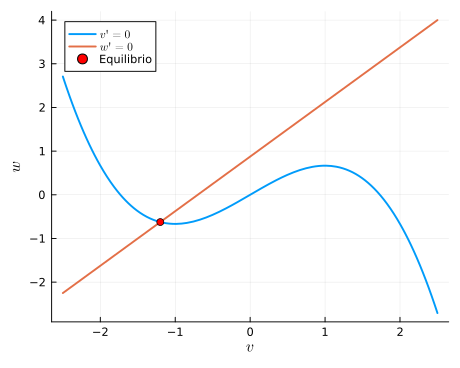

In [19]:
using Plots, LaTeXStrings
nv(v) = v - v^3/3 + I     # nulclina de v
nw(v) = (v + 0.7) / 0.8    # nulclina de w
plot(nv, -2.5, 2.5, lw = 2, label = L"v'=0", xlab = L"v", ylab = L"w")
plot!(nw, -2.5, 2.5, lw = 2, label = L"w'=0")
scatter!([eq[1]], [eq[2]], color = :red, label = "Equilibrio")

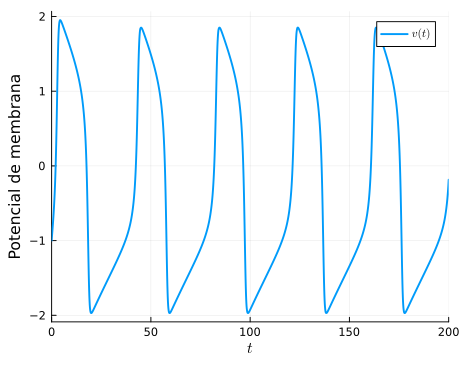

In [20]:
using DifferentialEquations
function fhn!(du, u, p, t)
    I = p
    du[1] = u[1] - u[1]^3/3 - u[2] + I
    du[2] = 0.08*(u[1] + 0.7 - 0.8u[2])
end
sol = solve(ODEProblem(fhn!, [-1.0, -0.5], (0.0, 200.0), 0.5), saveat = 0.1)
plot(sol, idxs = 1, lw = 2, label = L"v(t)", xlab = L"t",
     ylab = "Potencial de membrana")

In [21]:
using SymPyPythonCall
@syms x y
H = Sym(1)/2 * (x - log(x)) + (y - log(y))
dHdt = diff(H, x) * (x * (1 - y)) + diff(H, y) * (Sym(1)/2 * y * (x - 1))
simplify(dHdt)

0

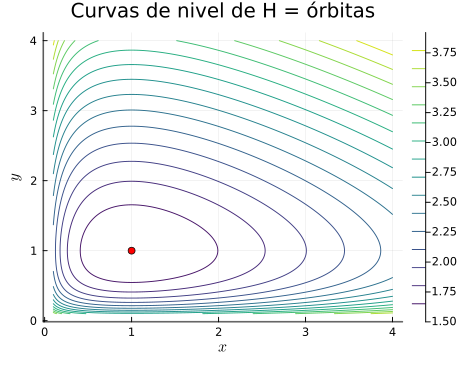

In [22]:
using Plots, LaTeXStrings
Hnum(x, y) = 0.5*(x - log(x)) + (y - log(y))
xs = ys = range(0.1, 4, length = 300)
contour(xs, ys, Hnum, levels = 15, xlab = L"x", ylab = L"y",
        color = :viridis, title = "Curvas de nivel de H = órbitas")
scatter!([1], [1], color = :red, label = "")